# Esercitazione 24 Marzo 2026

## Esercizio 1    

Si consideri la funzione $f(x) = 1 - \cos(x)$ per $x = 10^{-i}$, $i = 1, 2, \ldots, 15$.

1. Analizzare il condizionamento del problema calcolando il numero di condizionamento relativo: e discutere se il problema è ben condizionato al decrescere di $x$.

2. Valutare $f(x)$ con la formula diretta e confrontarla con la forma algebricamente equivalente che evita la cancellazione:
$$g(x) = \frac{\sin^2(x)}{1 + \cos(x)}$$
usando `np.cos` e `np.sin`. Calcolare l'errore relativo di $f(x)$ rispetto a $g(x)$.

3. Visualizzare su grafico l'errore relativo e il numero di condizionamento $K(x)$ al variare di $x$ (scala logaritmica sull'asse $x$).

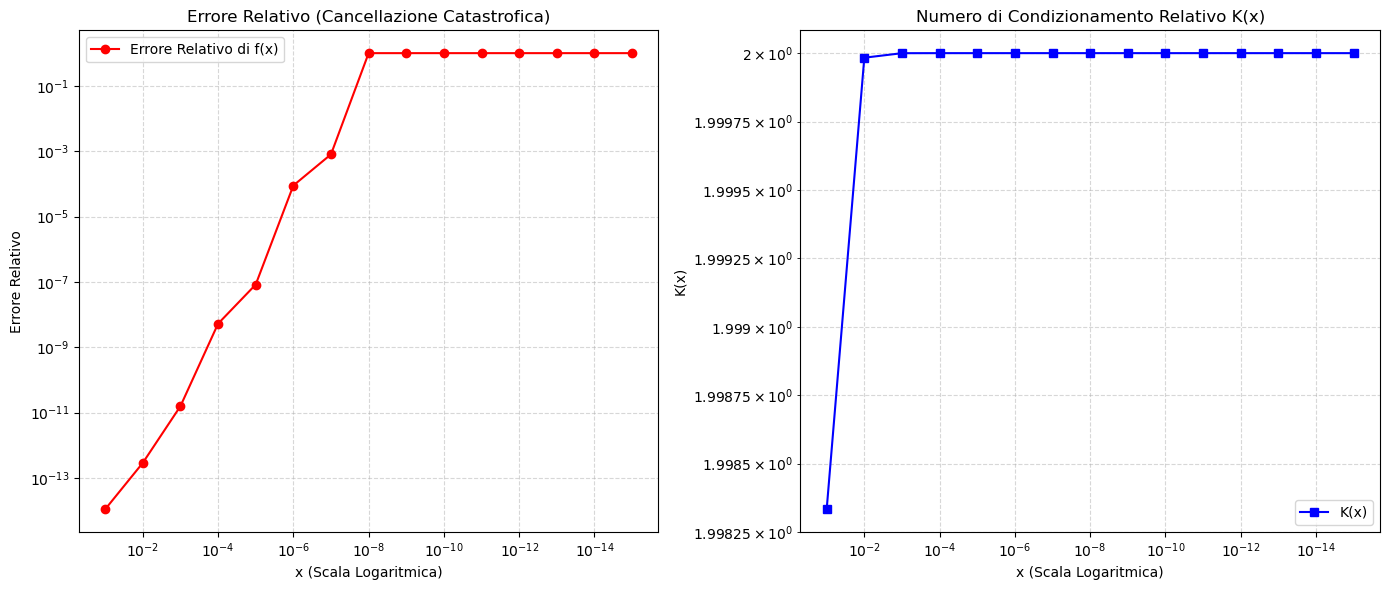

Confronto numerico per x piccoli:
x = 10^-1  | K(x) = 1.9983 | Err. Relativo = 1.09e-14
x = 10^-5  | K(x) = 2.0000 | Err. Relativo = 8.27e-08
x = 10^-8  | K(x) = 2.0000 | Err. Relativo = 1.00e+00
x = 10^-15 | K(x) = 2.0000 | Err. Relativo = 1.00e+00


In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Creazione del vettore x (da 10^-1 a 10^-15)
esponenti = np.arange(1, 16, dtype=np.float64)
x = 10.0 ** (-esponenti)

# Valutazione con la formula diretta f(x) (Instabile)
f = 1.0 - np.cos(x)

# Valutazione con la formula equivalente g(x) (Stabile e presa come valore esatto)
g = (np.sin(x)**2) / (1.0 + np.cos(x))

# Calcolo dell'errore relativo
errore_relativo = np.abs(f - g) / np.abs(g)

# Calcolo del numero di condizionamento K(x)
# Usiamo g al posto di f al denominatore per evitare divisioni per zero 
# quando f incappa nella cancellazione totale
K = np.abs((x * np.sin(x)) / g)

# ==========================================
# Visualizzazione dei Grafici
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Grafico 1: Errore Relativo
ax1.loglog(x, errore_relativo, marker='o', color='red', linestyle='-', label='Errore Relativo di f(x)')
ax1.set_title("Errore Relativo (Cancellazione Catastrofica)")
ax1.set_xlabel("x (Scala Logaritmica)")
ax1.set_ylabel("Errore Relativo")
# Invertiamo l'asse x per mostrare x che decresce verso zero da sinistra a destra
ax1.invert_xaxis() 
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.legend()

# Grafico 2: Numero di Condizionamento K(x)
ax2.loglog(x, K, marker='s', color='blue', linestyle='-', label='K(x)')
ax2.set_title("Numero di Condizionamento Relativo K(x)")
ax2.set_xlabel("x (Scala Logaritmica)")
ax2.set_ylabel("K(x)")
ax2.invert_xaxis()
ax2.grid(True, which="both", ls="--", alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

# Stampa di verifica per i valori critici
print("Confronto numerico per x piccoli:")
for i in [1, 5, 8, 15]:
    idx = i - 1
    print(f"x = 10^-{i:<2d} | K(x) = {K[idx]:.4f} | Err. Relativo = {errore_relativo[idx]:.2e}")

# Esercizio 2

Si consideri la funzione esponenziale

$$
e^x = \sum_{k=0}^{\infty} \frac{x^k}{k!}
$$

e la sua approssimazione tramite la serie di Taylor troncata.

 
-      Implementare una funzione che calcoli  e^x  utilizzando la serie di Taylor:
$$
e^x \approx \sum_{k=0}^{N} \frac{x^k}{k!}
$$
utilizzando aritmetica in **float32**.


-        Per i valori

$$
x \in \{-20, -10, -5, -1, 1, 5, 10\}
$$

calcolare:

- il valore approssimato tramite la serie di Taylor (N=1000)
- il valore di riferimento (ad esempio con `math.exp`)
- l’errore relativo


-      Rappresentare graficamente l’errore relativo al variare di \(x\).

-      Osservare e discutere il comportamento dell’errore nei due casi:           per  x > 0  e  per  x < 0 

e spiegare eventuali problemi di stabilità numerica.

-     Per migliorare la stabilità, utilizzare la relazione:

$$
e^x = \frac{1}{e^{-x}}
$$

e implementare una versione alternativa dell’algoritmo.

Confrontare i risultati ottenuti con quelli del metodo diretto.


-     Implementare una variante dell’algoritmo in cui:

-      si sommano separatamente i termini positivi
-      si sommano i valori assoluti dei termini negativi
-      si calcola il risultato finale come differenza tra le due somme
  $S = S_+ - S_-$

Confrontare i risultati con quelli del metodo diretto e del metodo stabile.


In [44]:
import numpy as np

N = 1000
x32 = np.array([-20, -10, -5, -1, 1, 5, 10], dtype=np.float32)
x64 = np.array([-20.0, -10, -5, -1, 1, 5, 10])
rif = np.exp(x64)

# ==========================================
# 1. Metodo Diretto (Instabile per x < 0)
# ==========================================
def serieTaylor(x, N):
    s = np.float32(1.0)
    ter = np.float32(1.0)
    for k in range(1, N):
        ter = ter * x/k
        s = s + ter
    return s

# ==========================================
# 2. Metodo Stabile (Reciproco per x < 0)
# ==========================================
def serieTaylor_stable(x, N):
    s_val = serieTaylor(np.abs(x), N)
    return np.float32(1.0) / s_val

# ==========================================
# 3. Metodo a Somme Separate (Split)
# ==========================================
def serieTaylor_split(x, N):
    s_pos = np.float32(1.0)  # Il primo termine (k=0) vale 1, ed è positivo
    s_neg = np.float32(0.0)
    ter = np.float32(1.0)
    
    for k in range(1, N+1):
        ter = ter * x/k
        if ter > 0:
            s_pos = s_pos + ter
        else:
            # Sommiamo il valore assoluto alla fazione negativa
            s_neg = s_neg + np.abs(ter)
            
    # Alla fine calcoliamo la differenza tra le due somme colossali
    return s_pos - s_neg

# ==========================================
# Esecuzione e Calcolo Errori
# ==========================================
err_diretto = []
err_stable = []
err_split = []

print(f"{'x':>5} | {'Err. Diretto':>13} | {'Err. Stabile':>13} | {'Err. Split':>13}")
print("-" * 55)

for i, x in enumerate(x32):
    # Calcolo dei tre risultati
    res_dir = serieTaylor(x, N)
    res_sta = serieTaylor_stable(x, N)
    res_spl = serieTaylor_split(x, N)
    
    val_rif = rif[i]
    
    # Calcolo errori relativi
    e_dir = np.abs(res_dir - val_rif) / np.abs(val_rif)
    e_sta = np.abs(res_sta - val_rif) / np.abs(val_rif)
    e_spl = np.abs(res_spl - val_rif) / np.abs(val_rif)
    
    err_diretto.append(e_dir)
    err_stable.append(e_sta)
    err_split.append(e_spl)
    
    print(f"{x:5.1f} | {e_dir:13.2e} | {e_sta:13.2e} | {e_spl:13.2e}")

    x |  Err. Diretto |  Err. Stabile |    Err. Split
-------------------------------------------------------
-20.0 |      1.34e+09 |      7.39e-08 |      7.76e+09
-10.0 |      2.38e+00 |      1.34e-07 |      1.00e+00
 -5.0 |      7.07e-05 |      2.07e-07 |      9.55e-04
 -1.0 |      1.37e-07 |      5.61e-08 |      1.87e-07
  1.0 |      5.73e-08 |      8.65e-01 |      5.73e-08
  5.0 |      2.27e-07 |      1.00e+00 |      2.27e-07
 10.0 |      1.34e-07 |      1.00e+00 |      1.34e-07


## Esercizio 3  

Si consideri la funzione $f(x) = x^n$ valutata nel punto  $x_0 = 0.999$
al variare dell'esponente $n = 1, 2, \ldots, 200$.

-  Calcolare l'indice di condizionamento del problema

-  perturbare $x_0$  e misurare la variazione relativa del risultato:
$$\frac{|f(x_0 + \delta x) - f(x_0)|}{|f(x_0)|}$$
   

Si scelga come perturbazione $\delta x = \varepsilon \cdot x_0$

1. Calcolare la variazione relativa misurata
   $e_{\rm mis}(n) = |f(x_0 + \delta x) - f(x_0)| / |f(x_0)|$
   e confrontarla con la previsione $K(n)$ teorica 
   
2. Verificare che le due curve coincidono
3. Visualizzare su grafico la variazione relativa e il bound $K(n) \cdot \varepsilon$    al variare di $n$, e separatamente $K(n)$.

## Esercizio 4 

Si consideri la funzione $f(x) = \ln(x)$ per $x$ sempre più vicino a $1$

 $f(x) = \ln(x)$ per $x = 1 + 10^{-i}$, $i = 0, \ldots, 15$

-  Calcolo indice di condizionamento del problema
-  Perturbare $x$ di $\delta x = \varepsilon  \cdot x$ e misurare
   $e_{\rm mis}(x) = |f(x+\delta x) - f(x)| / |f(x)|$.
-  Confrontare $e_{\rm mis}$ con la previsione $K(x) \cdot \varepsilon$.
-  Visualizzare su grafico le due curve e $K(x)$ al variare di $i$.